In [17]:
# Cella 1 - Import librerie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from wordcloud import WordCloud
import re
from collections import Counter

print("✅ Librerie caricate!")

✅ Librerie caricate!


In [24]:
# Cella 2 - Carica i tuoi proverbi dal database
import sqlite3
import pandas as pd

# Connettiti al database
conn = sqlite3.connect('archivio.db')

# Carica i proverbi italiani
df_proverbi = pd.read_sql_query("""
    SELECT id, testo, significato, categoria_id, data_ins 
    FROM proverbi 
    ORDER BY testo
""", conn)

# Chiudi connessione
conn.close()

# Mostra le prime righe
print(f"📖 Caricati {len(df_proverbi)} proverbi")
print("\nPrime 5 righe:")
df_proverbi.head()

📖 Caricati 10 proverbi

Prime 5 righe:


,id,testo,significato,categoria_id,data_ins
0,5,A tavola non si invecchia.,Il momento del pasto è piacevole e rigenerante.,5,2026-03-10 10:03:08
1,1,Chi dorme non piglia pesci.,Chi non si impegna non ottiene risultati.,3,2026-03-10 10:03:08
2,6,Chi trova un amico trova un tesoro.,L'amicizia vera è un bene prezioso.,6,2026-03-10 10:03:08
3,3,Il lupo perde il pelo ma non il vizio.,Le abitudini profonde non cambiano facilmente.,1,2026-03-10 10:03:08
4,18,Inserisci qui il testo del tuo proverbio,Inserisci il significato o la spiegazione,15,2026-03-10 10:04:21


In [19]:
# Cella 3 - Statistiche base
print("📊 STATISTICHE PROVERBI")
print("-" * 40)
print(f"Totale proverbi: {len(df_proverbi)}")
print(f"Temi unici: {df_proverbi['testo'].nunique()}")
print(f"Significati unici: {df_proverbi['significato'].nunique()}")

print("\n🏷️ Temi più frequenti:")
print(df_proverbi['testo'].value_counts().head(10))

📊 STATISTICHE PROVERBI
----------------------------------------
Totale proverbi: 10
Temi unici: 10
Significati unici: 9

🏷️ Temi più frequenti:
testo
A tavola non si invecchia.                  1
Chi dorme non piglia pesci.                 1
Chi trova un amico trova un tesoro.         1
Il lupo perde il pelo ma non il vizio.      1
Inserisci qui il testo del tuo proverbio    1
L'abito non fa il monaco.                   1
Meglio tardi che mai.                       1
Rosso di sera bel tempo si spera.           1
Rosso di sera, bel tempo si spera.          1
Tra moglie e marito non mettere il dito.    1
Name: count, dtype: int64


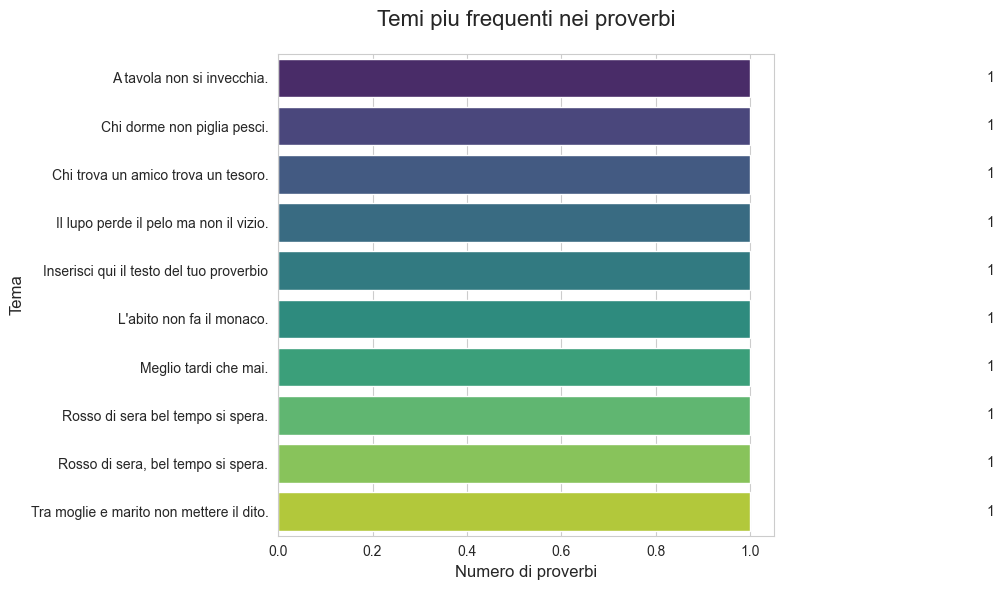


Temi con piu proverbi:
  • A tavola non si invecchia.: 1 proverbi
  • Chi dorme non piglia pesci.: 1 proverbi
  • Chi trova un amico trova un tesoro.: 1 proverbi
  • Il lupo perde il pelo ma non il vizio.: 1 proverbi
  • Inserisci qui il testo del tuo proverbio: 1 proverbi


In [26]:
# Cella 4 - Grafico dei temi (versione senza emoji)
import matplotlib.pyplot as plt
import seaborn as sns

# Imposta lo stile
sns.set_style("whitegrid")

# Prepara i dati
temi_counts = df_proverbi['testo'].value_counts().head(10).reset_index()
temi_counts.columns = ['testo', 'conteggio']

# Crea il grafico
plt.figure(figsize=(12, 6))
bars = sns.barplot(
    data=temi_counts, 
    x='conteggio', 
    y='testo',
    hue='testo',
    palette='viridis',
    legend=False
)

# Personalizza (SENZA EMOJI)
plt.title('Temi piu frequenti nei proverbi', fontsize=16, pad=20)
plt.xlabel('Numero di proverbi', fontsize=12)
plt.ylabel('Tema', fontsize=12)

# Aggiungi i numeri sulle barre
for i, (value, name) in enumerate(zip(temi_counts['conteggio'], temi_counts['testo'])):
    plt.text(value + 0.5, i, str(value), va='center')

plt.tight_layout()
plt.show()

print("\nTemi con piu proverbi:")
for idx, row in temi_counts.head(5).iterrows():
    print(f"  • {row['testo']}: {row['conteggio']} proverbi")

📏 STATISTICHE LUNGHEZZA
------------------------------
Media: 31.9 caratteri
Mediana: 33.5 caratteri
Massimo: 40 caratteri
Minimo: 21 caratteri

📜 Proverbio più lungo (40 caratteri):
  "Inserisci qui il testo del tuo proverbio"
  — Inserisci il significato o la spiegazione (Inserisci qui il testo del tuo proverbio)

📜 Proverbio più corto (21 caratteri):
  "Meglio tardi che mai."
  — È preferibile fare una cosa in ritardo che non farla. (Meglio tardi che mai.)


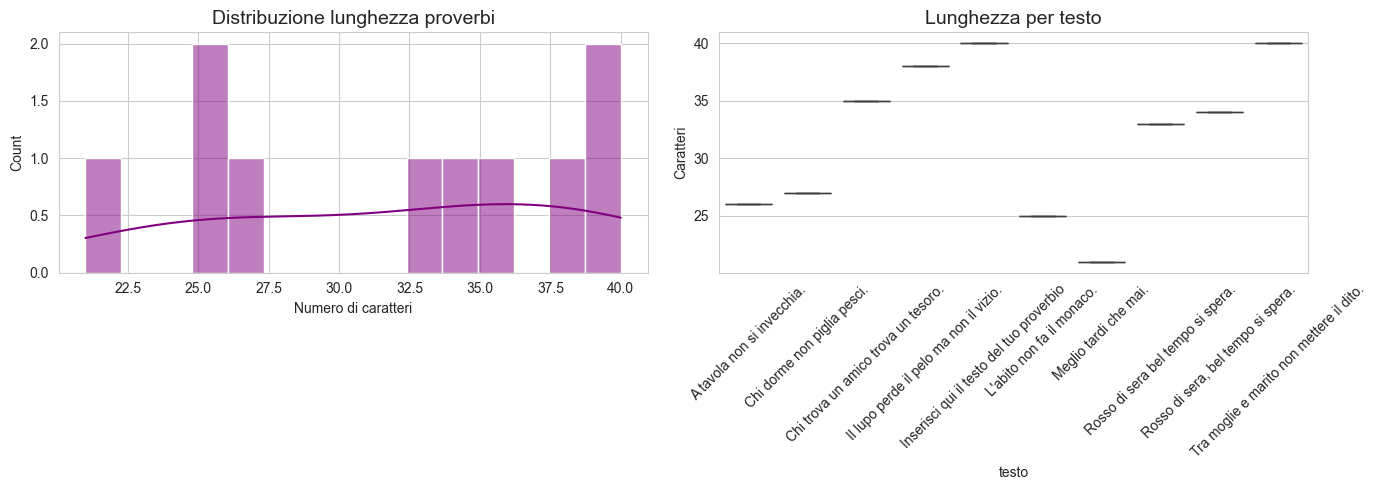

In [21]:
# Cella 5 - Analisi lunghezza
# Aggiungi colonna lunghezza
df_proverbi['lunghezza'] = df_proverbi['testo'].str.len()

# Statistiche
print("📏 STATISTICHE LUNGHEZZA")
print("-" * 30)
print(f"Media: {df_proverbi['lunghezza'].mean():.1f} caratteri")
print(f"Mediana: {df_proverbi['lunghezza'].median():.1f} caratteri")
print(f"Massimo: {df_proverbi['lunghezza'].max()} caratteri")
print(f"Minimo: {df_proverbi['lunghezza'].min()} caratteri")

# Trova il proverbio più lungo e più corto
piu_lungo = df_proverbi.loc[df_proverbi['lunghezza'].idxmax()]
piu_corto = df_proverbi.loc[df_proverbi['lunghezza'].idxmin()]

print(f"\n📜 Proverbio più lungo ({piu_lungo['lunghezza']} caratteri):")
print(f"  \"{piu_lungo['testo']}\"")
print(f"  — {piu_lungo['significato']} ({piu_lungo['testo']})")

print(f"\n📜 Proverbio più corto ({piu_corto['lunghezza']} caratteri):")
print(f"  \"{piu_corto['testo']}\"")
print(f"  — {piu_corto['significato']} ({piu_corto['testo']})")

# Grafico distribuzione
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_proverbi['lunghezza'], bins=15, kde=True, color='purple')
plt.title('Distribuzione lunghezza proverbi', fontsize=14)
plt.xlabel('Numero di caratteri')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_proverbi, x='testo', y='lunghezza')
plt.title('Lunghezza per testo', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Caratteri')

plt.tight_layout()
plt.show()

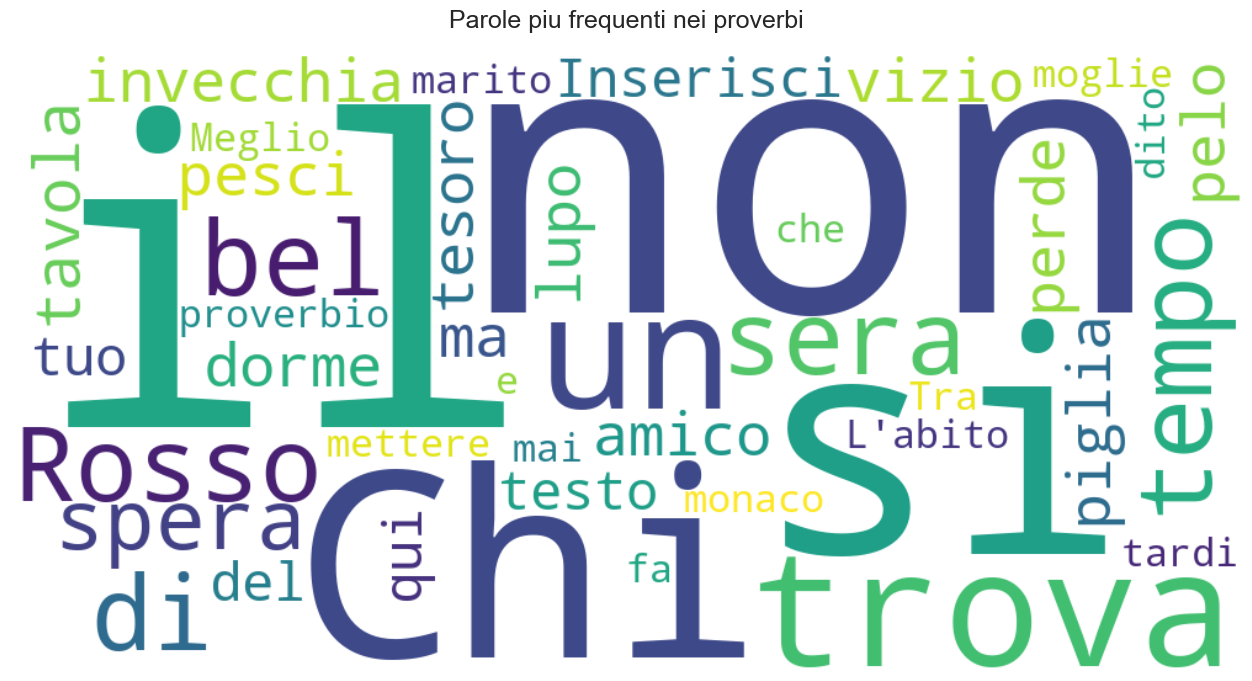

In [22]:
# Cella 6 - WordCloud (senza emoji)
from wordcloud import WordCloud

# Se non hai wordcloud, installalo in una cella:
# !pip install wordcloud

# Unisci tutti i proverbi in un unico testo
testo_completo = ' '.join(df_proverbi['testo'].tolist())

# Crea la wordcloud
wordcloud = WordCloud(
    width=1000, 
    height=500, 
    background_color='white',
    colormap='viridis',
    max_words=100,
    contour_width=1,
    contour_color='steelblue',
    random_state=42
).generate(testo_completo)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Parole piu frequenti nei proverbi', fontsize=18, pad=20)  # ← Senza emoji
plt.show()

In [23]:
# Cella 7 - Parole più frequenti per tema
from collections import Counter
import re

# Scegli un tema (cambia con uno dei tuoi)
tema_scelto = 'amore'  # Puoi cambiare con 'lavoro', 'vita', ecc.

# Filtra proverbi del tema scelto
df_tema = df_proverbi[df_proverbi['testo'] == tema_scelto]

if len(df_tema) > 0:
    print(f"📖 Analisi tema: {tema_scelto.upper()} ({len(df_tema)} testo)")
    
    # Unisci tutti i testi
    testo_tema = ' '.join(df_tema['testo'].tolist()).lower()
    
    # Estrai parole (rimuovi punteggiatura)
    parole = re.findall(r'\b[a-z]+\b', testo_tema)
    
    # Conta
    parole_comuni = Counter(parole).most_common(15)
    
    print("\nParole più frequenti:")
    for parola, count in parole_comuni:
        print(f"  • {parola}: {count} volte")
    
    # Grafico
    plt.figure(figsize=(10, 6))
    parole, conteggi = zip(*parole_comuni)
    plt.barh(parole, conteggi, color='coral')
    plt.title(f'Parole più frequenti nel tema "{tema_scelto}"', fontsize=16)
    plt.xlabel('Frequenza')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print(f"Nessun proverbio trovato per il tema '{tema_scelto}'")

Nessun proverbio trovato per il tema 'amore'
